In [ ]:
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold

from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [14]:
def load_train_test(train_path, test_path, target_col="is_fraud"):
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col].astype(int)

    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col].astype(int)

    return X_train, y_train, X_test, y_test


In [ ]:
def evaluate_and_save_results(model, X, y, json_path="results/evaluation_results.json", threshold=0.5):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(y, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y, y_prob)
    avg_precision = average_precision_score(y, y_prob)

    fpr, tpr, roc_thresholds = roc_curve(y, y_prob)
    precision, recall, pr_thresholds = precision_recall_curve(y, y_prob)

    cm = confusion_matrix(y, y_pred, labels=[0, 1])

    results = {
        "threshold_used": float(threshold),
        "classification_report": report,
        "roc_auc": float(roc_auc),
        "average_precision": float(avg_precision),
        "confusion_matrix": {"labels": [0, 1], "matrix": cm.tolist()},
        "roc_curve": {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "thresholds": roc_thresholds.tolist()},
        "precision_recall_curve": {"precision": precision.tolist(), "recall": recall.tolist(), "thresholds": pr_thresholds.tolist()},
    }

    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    return results


In [ ]:
X_train_full, y_train_full, X_test, y_test = load_train_test(PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/train.csv", PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/test.csv")

print("Train:", X_train_full.shape, " Test:", X_test.shape)
print("Train class counts:\n", y_train_full.value_counts())
print("Test class counts:\n", y_test.value_counts())

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print("\nTrain split:", X_tr.shape, " Val split:", X_val.shape)
print("Train split fraud rate:", y_tr.mean(), " Val fraud rate:", y_val.mean())


Train: (239756, 21)  Test: (59939, 21)
Train class counts:
 is_fraud
0    234466
1      5290
Name: count, dtype: int64
Test class counts:
 is_fraud
0    58617
1     1322
Name: count, dtype: int64

Train split: (191804, 21)  Val split: (47952, 21)
Train split fraud rate: 0.022064190527830492  Val fraud rate: 0.02206373039706373


In [17]:
cat_cols = ["country", "bin_country", "merchant_category"]
num_cols = [c for c in X_tr.columns if c not in cat_cols]

# Robust OneHotEncoder across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))


Numeric cols: 18 Categorical cols: 3


In [18]:
def best_threshold_by_fbeta(y_true, y_prob, beta=2.0):
    prec, rec, ths = precision_recall_curve(y_true, y_prob)

    # ths length is len(prec)-1
    prec = prec[:-1]
    rec  = rec[:-1]

    beta2 = beta**2
    fbeta = (1 + beta2) * (prec * rec) / (beta2 * prec + rec + 1e-12)

    best_idx = np.argmax(fbeta)
    return float(ths[best_idx]), float(prec[best_idx]), float(rec[best_idx]), float(fbeta[best_idx])


In [19]:
def train_and_tune_linear_svm(X_tr, y_tr, X_val, y_val, preprocessor):

    fraud_weights = [10, 20, 30, 50]
    Cs = [0.1, 0.5, 1.0]               # regularization strength

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    best = None

    for w in fraud_weights:
        for C in Cs:
            base = LinearSVC(
                C=C,
                class_weight={0: 1, 1: w},
                max_iter=20000,
                tol=1e-4,
                random_state=42
            )

            cal = CalibratedClassifierCV(estimator=base, cv=cv, method="sigmoid")

            model = Pipeline(steps=[
                ("preprocess", preprocessor),
                ("svm", cal)
            ])

            model.fit(X_tr, y_tr)

            val_prob = model.predict_proba(X_val)[:, 1]
            th, p, r, f2 = best_threshold_by_fbeta(y_val, val_prob, beta=2.0)

            if best is None or f2 > best["f2"]:
                best = {
                    "fraud_weight": w,
                    "C": C,
                    "threshold": th,
                    "val_precision": p,
                    "val_recall": r,
                    "f2": f2,
                    "model": model
                }

            print(f"w={w:>2}  C={C:<3}  best_th={th:.4f}  val_P={p:.3f}  val_R={r:.3f}  F2={f2:.3f}")

    return best

best = train_and_tune_linear_svm(X_tr, y_tr, X_val, y_val, preprocessor)

print("\nBEST SETTINGS:")
print(best)


w=10  C=0.1  best_th=0.1137  val_P=0.359  val_R=0.650  F2=0.559
w=10  C=0.5  best_th=0.1137  val_P=0.359  val_R=0.650  F2=0.559
w=10  C=1.0  best_th=0.1137  val_P=0.359  val_R=0.650  F2=0.559
w=20  C=0.1  best_th=0.1172  val_P=0.361  val_R=0.647  F2=0.558
w=20  C=0.5  best_th=0.1172  val_P=0.361  val_R=0.647  F2=0.558
w=20  C=1.0  best_th=0.1172  val_P=0.361  val_R=0.647  F2=0.558
w=30  C=0.1  best_th=0.1174  val_P=0.360  val_R=0.646  F2=0.557
w=30  C=0.5  best_th=0.1174  val_P=0.360  val_R=0.646  F2=0.557
w=30  C=1.0  best_th=0.1174  val_P=0.360  val_R=0.646  F2=0.557
w=50  C=0.1  best_th=0.1147  val_P=0.354  val_R=0.648  F2=0.556
w=50  C=0.5  best_th=0.1147  val_P=0.353  val_R=0.648  F2=0.556
w=50  C=1.0  best_th=0.1147  val_P=0.353  val_R=0.648  F2=0.556

BEST SETTINGS:
{'fraud_weight': 10, 'C': 0.1, 'threshold': 0.1136740492332957, 'val_precision': 0.3588941053729786, 'val_recall': 0.6502835538752363, 'f2': 0.5594405594402913, 'model': Pipeline(steps=[('preprocess',
               

In [20]:
val_prob = best["model"].predict_proba(X_val)[:, 1]
val_pred = (val_prob >= best["threshold"]).astype(int)

print("Validation classification report (threshold tuned for F2):")
print(classification_report(y_val, val_pred))


Validation classification report (threshold tuned for F2):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     46894
           1       0.36      0.65      0.46      1058

    accuracy                           0.97     47952
   macro avg       0.68      0.81      0.72     47952
weighted avg       0.98      0.97      0.97     47952



In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

final_base = LinearSVC(
    C=best["C"],
    class_weight={0: 1, 1: best["fraud_weight"]},
    max_iter=20000,
    tol=1e-4,
    random_state=42
)

final_cal = CalibratedClassifierCV(estimator=final_base, cv=cv, method="sigmoid")

final_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", final_cal)
])

final_model.fit(X_train_full, y_train_full)

results = evaluate_and_save_results(
    final_model,
    X_test,
    y_test,
    json_path="results/linear_svm_evaluation_results.json",
    threshold=best["threshold"]
)

print("Test classification report (FINAL):")
print(results["classification_report"])
print("\nROC-AUC:", results["roc_auc"])
print("PR-AUC (Average Precision):", results["average_precision"])
print("Threshold used:", results["threshold_used"])


Test classification report (FINAL):
{'0': {'precision': 0.9917762587182067, 'recall': 0.9752119692239453, 'f1-score': 0.9834243688443508, 'support': 58617.0}, '1': {'precision': 0.368535419382877, 'recall': 0.6414523449319214, 'f1-score': 0.4681203422577974, 'support': 1322.0}, 'accuracy': 0.9678506481589616, 'macro avg': {'precision': 0.6801558390505419, 'recall': 0.8083321570779334, 'f1-score': 0.7257723555510741, 'support': 59939.0}, 'weighted avg': {'precision': 0.9780302104090707, 'recall': 0.9678506481589616, 'f1-score': 0.9720589486146601, 'support': 59939.0}}

ROC-AUC: 0.9374303876826818
PR-AUC (Average Precision): 0.5380392293125698
Threshold used: 0.1136740492332957


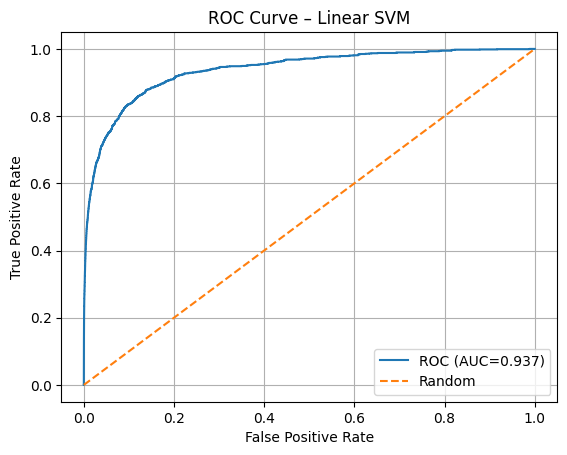

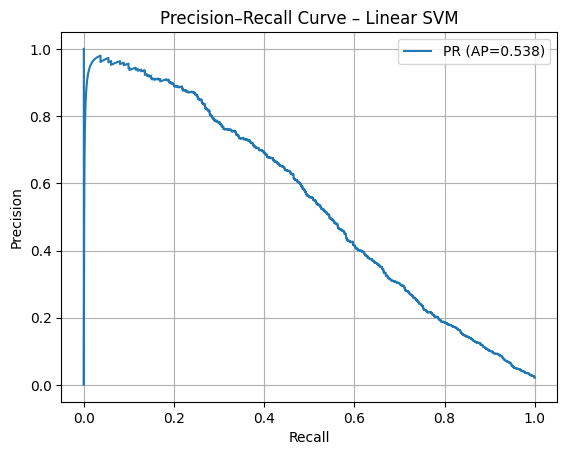

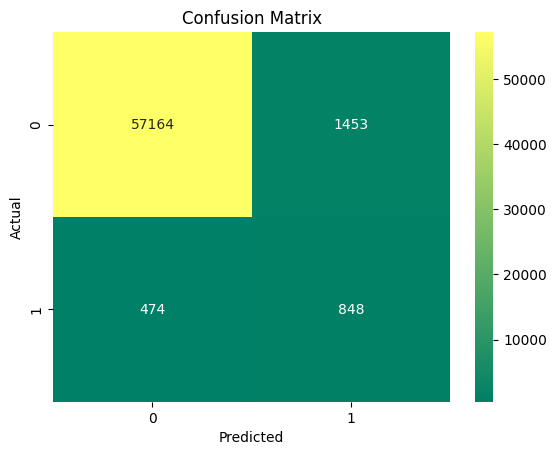

In [24]:
# ROC
fpr = results["roc_curve"]["fpr"]
tpr = results["roc_curve"]["tpr"]
roc_auc = results["roc_auc"]

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Linear SVM")
plt.legend()
plt.grid(True)
plt.show()

# PR
precision = results["precision_recall_curve"]["precision"]
recall = results["precision_recall_curve"]["recall"]
ap = results["average_precision"]

plt.figure()
plt.plot(recall, precision, label=f"PR (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Linear SVM")
plt.legend()
plt.grid(True)
plt.show()

# Confusion matrix
cm = np.array(results["confusion_matrix"]["matrix"])

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=[0,1], yticklabels=[0,1], cmap="summer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix")
plt.show()
